In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon, pearsonr, spearmanr
from itertools import combinations

# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------
FILES = {
    "II": "main_results/filtered_iterative_improvement_results.csv",
    "VND": "main_results/filtered_vnd_results.csv",
    "RII": "main_results/rii_results.csv",
    "VNS": "main_results/vns_results.csv",
}

ALPHA = 0.05

In [ ]:

# ------------------------------------------------------------
# Load and standardize data
# ------------------------------------------------------------
all_data = []

for method, path in FILES.items():
    df = pd.read_csv(path)

    if method in ["II", "RII"]:
        df["algorithm"] = (
            method + "_" +
            df["pivoting_rule"].astype(str) + "_" +
            df["neighborhood"].astype(str) + "_" +
            df["initial_solution"].astype(str)
        )
    else:
        df["algorithm"] = method + "_" + df["order"].astype(str)

    df["method"] = method

    all_data.append(
        df[[
            "instance",
            "method",
            "algorithm",
            "best_known",
            "cost",
            "delta_percent",
            "time_seconds"
        ]]
    )

data = pd.concat(all_data, ignore_index=True)

# Safety check: only size-150 instances
data = data[data["instance"].str.contains("_150")].copy()

# data.to_csv("combined_results.csv", index=False, sep=",")

data

,instance,method,algorithm,best_known,cost,delta_percent,time_seconds
0,N-tiw56r66_150,II,II_best_insert_cw,1940755,1892893,2.466154,0.088860
1,N-stabu1_150,II,II_best_insert_cw,2875732,2820215,1.930535,0.101848
2,N-tiw56r67_150,II,II_best_insert_cw,2056347,2015860,1.968880,0.086903
3,N-tiw56n72_150,II,II_best_insert_cw,4135907,4024242,2.699891,0.086619
4,N-stabu3_150,II,II_best_insert_cw,4510445,4427867,1.830817,0.083088
...,...,...,...,...,...,...,...
151,N-be75np_150,VNS,VNS_order2,7174325,7058778,1.610563,80.604781
152,N-t65l11xx_150,VNS,VNS_order2,253396,251639,0.693381,80.604567
153,N-t59b11xx_150,VNS,VNS_order2,3239550,3198940,1.253569,80.607102
154,N-t59d11xx_150,VNS,VNS_order2,1462697,1438862,1.629524,80.604048


In [12]:

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------
summary = (
    data.groupby(["method", "algorithm"], as_index=False)
    .agg(
        n_instances=("instance", "nunique"),
        avg_deviation_percent=("delta_percent", "mean"),
        std_deviation_percent=("delta_percent", "std"),
        median_deviation_percent=("delta_percent", "median"),
        min_deviation_percent=("delta_percent", "min"),
        max_deviation_percent=("delta_percent", "max"),
        total_time_seconds=("time_seconds", "sum"),
        avg_time_seconds=("time_seconds", "mean"),
    )
    .sort_values("avg_deviation_percent")
)

summary.to_csv("summary_sls_results.csv", index=False)
summary

,method,algorithm,n_instances,avg_deviation_percent,std_deviation_percent,median_deviation_percent,min_deviation_percent,max_deviation_percent,total_time_seconds,avg_time_seconds
1,RII,RII_best_insert_cw,39,0.756581,0.252069,0.733785,0.273513,1.412550,3143.575014,80.604488
3,VNS,VNS_order2,39,1.200233,0.375686,1.227468,0.320925,2.099140,3143.637874,80.606099
2,VND,VND_order2,39,2.038644,0.495124,1.945042,1.090783,3.084416,5.248118,0.134567
0,II,II_best_insert_cw,39,2.244693,0.425449,2.294678,1.425437,3.413893,3.405902,0.087331


In [27]:
# ------------------------------------------------------------
# Pairwise statistical comparisons
# ------------------------------------------------------------
def compare_algorithms(data, alg1, alg2):
    d1 = data[data["method"] == alg1][["instance", "delta_percent", "time_seconds"]]
    d2 = data[data["method"] == alg2][["instance", "delta_percent", "time_seconds"]]

    d1 = d1.rename(columns={"delta_percent": "delta_1", "time_seconds": "time_1"})
    d2 = d2.rename(columns={"delta_percent": "delta_2", "time_seconds": "time_2"})

    merged = pd.merge(d1, d2, on="instance", how="inner")

    x = merged["delta_1"]
    y = merged["delta_2"]

    t_stat, p_ttest = ttest_rel(x, y)

    try:
        w_stat, p_wilcoxon = wilcoxon(x, y, zero_method="wilcox")
    except ValueError:
        w_stat, p_wilcoxon = float("nan"), float("nan")

    mean_1 = x.mean()
    mean_2 = y.mean()

    if mean_1 < mean_2:
        better = alg1
    elif mean_2 < mean_1:
        better = alg2
    else:
        better = "tie"

    return {
        "algorithm_1": alg1,
        "algorithm_2": alg2,
        "n_instances": len(merged),
        "mean_delta_1": mean_1,
        "mean_delta_2": mean_2,
        "mean_diff_1_minus_2": (x - y).mean(),
        "better_by_mean": better,
        "p_value_ttest": p_ttest,
        "significant_ttest": p_ttest < ALPHA,
        "p_value_wilcoxon": p_wilcoxon,
        "significant_wilcoxon": p_wilcoxon < ALPHA,
        "avg_time_1": merged["time_1"].mean(),
        "avg_time_2": merged["time_2"].mean(),
    }

algorithms = sorted(data["method"].unique())

pairwise_results = pd.DataFrame([
    compare_algorithms(data, alg1, alg2)
    for alg1, alg2 in combinations(algorithms, 2)
])

pairwise_results = pairwise_results.sort_values(
    ["p_value_wilcoxon", "p_value_ttest"]
).reset_index(drop=True)

# pairwise_results.to_csv("pairwise_sls_comparisons.csv", index=False)
pairwise_results

,algorithm_1,algorithm_2,n_instances,mean_delta_1,mean_delta_2,mean_diff_1_minus_2,better_by_mean,p_value_ttest,significant_ttest,p_value_wilcoxon,significant_wilcoxon,avg_time_1,avg_time_2
0,II,RII,39,2.244693,0.756581,1.488112,RII,5.775115e-25,True,3.637979e-12,True,0.087331,80.604488
1,RII,VND,39,0.756581,2.038644,-1.282064,RII,1.711846e-18,True,3.637979e-12,True,80.604488,0.134567
2,II,VNS,39,2.244693,1.200233,1.044460,VNS,3.224016e-14,True,3.637979e-12,True,0.087331,80.606099
3,VND,VNS,39,2.038644,1.200233,0.838411,VNS,1.141739e-09,True,4.587491e-09,True,0.134567,80.606099
4,RII,VNS,39,0.756581,1.200233,-0.443652,RII,2.824621e-09,True,2.087472e-08,True,80.604488,80.606099
5,II,VND,39,2.244693,2.038644,0.206048,VND,2.023060e-02,True,1.159097e-02,True,0.087331,0.134567


In [28]:
# keep columns algorithm_1,algorithm_2,  significant_ttest, significant_wilcoxon]
pairwise_results_filtered = pairwise_results[
    ["algorithm_1", "algorithm_2", "significant_ttest", "significant_wilcoxon"]]

pairwise_results_filtered

,algorithm_1,algorithm_2,significant_ttest,significant_wilcoxon
0,II,RII,True,True
1,RII,VND,True,True
2,II,VNS,True,True
3,VND,VNS,True,True
4,RII,VNS,True,True
5,II,VND,True,True


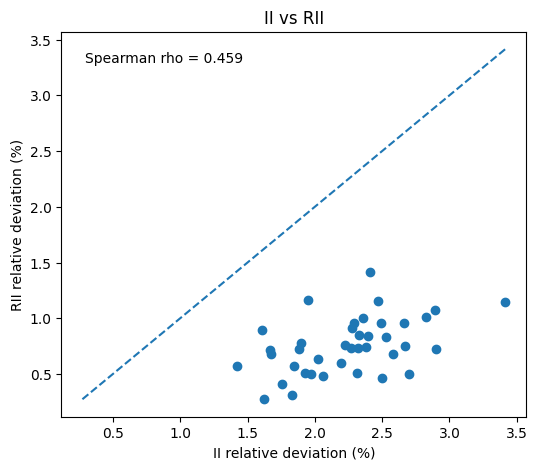

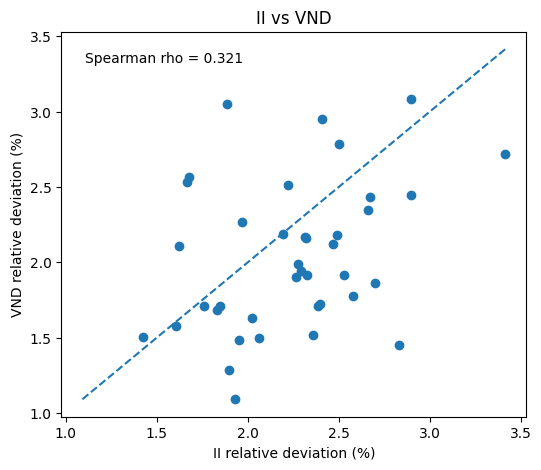

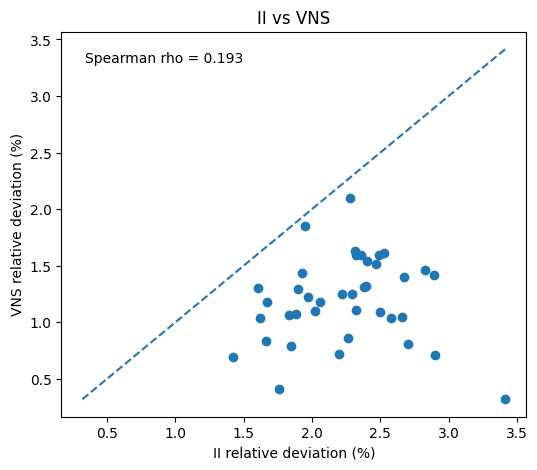

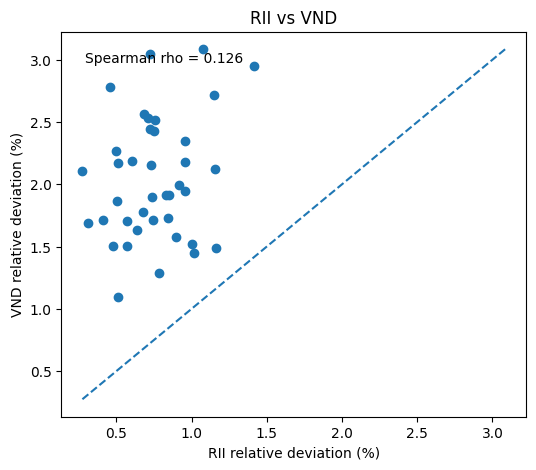

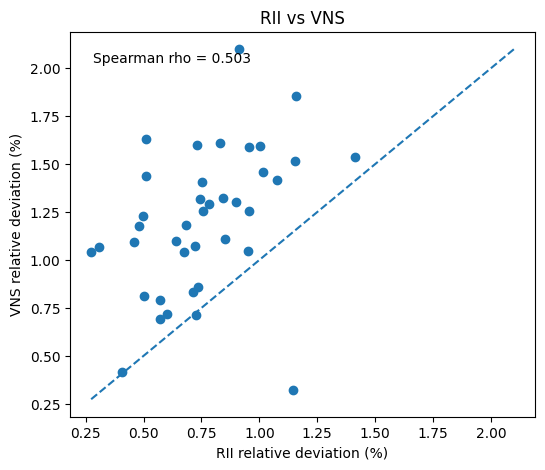

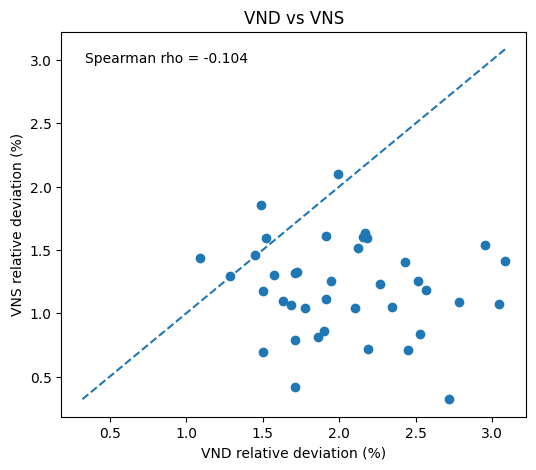

,algorithm_1,algorithm_2,pearson_r,pearson_p,spearman_rho,spearman_p
0,II,RII,0.476313,0.002175,0.459312,0.003268
1,II,VND,0.342505,0.032812,0.321457,0.045988
2,II,VNS,0.043596,0.792145,0.192713,0.239838
3,RII,VND,0.236471,0.147237,0.125506,0.446477
4,RII,VNS,0.397318,0.012260,0.503036,0.001099
5,VND,VNS,-0.113263,0.492381,-0.104251,0.527655


In [30]:

# ------------------------------------------------------------
# Correlation plots
# ------------------------------------------------------------
def make_correlation_plot(data, alg1, alg2):
    d1 = data[data["method"] == alg1][["instance", "delta_percent"]]
    d2 = data[data["method"] == alg2][["instance", "delta_percent"]]

    d1 = d1.rename(columns={"delta_percent": "delta_1"})
    d2 = d2.rename(columns={"delta_percent": "delta_2"})

    merged = pd.merge(d1, d2, on="instance", how="inner")

    pearson = pearsonr(merged["delta_1"], merged["delta_2"])
    spearman = spearmanr(merged["delta_1"], merged["delta_2"])

    plt.figure(figsize=(6, 5))
    plt.scatter(merged["delta_1"], merged["delta_2"])
    plt.xlabel(f"{alg1} relative deviation (%)")
    plt.ylabel(f"{alg2} relative deviation (%)")
    plt.title(f"{alg1} vs {alg2}")

    max_val = max(merged["delta_1"].max(), merged["delta_2"].max())
    min_val = min(merged["delta_1"].min(), merged["delta_2"].min())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.text(
        0.05,
        0.95,
        f"Spearman rho = {spearman.statistic:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    # plt.tight_layout()
    # filename = f"correlation_{alg1}_vs_{alg2}.png".replace("/", "_")
    # plt.savefig(filename, dpi=300)
    # plt.close()

    plt.show()

    return {
        "algorithm_1": alg1,
        "algorithm_2": alg2,
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
    }

correlations = pd.DataFrame([
    make_correlation_plot(data, alg1, alg2)
    for alg1, alg2 in combinations(algorithms, 2)
])

# correlations.to_csv("correlation_results.csv", index=False)
correlations